# Strategic Credit Card Customer Segmentation

**Objective:** Build an end-to-end unsupervised learning pipeline to group credit card holders into distinct, actionable customer personas, comparing multiple clustering algorithms, and delivering targeted marketing recommendations.

---



### Objective
This project analyzes the transaction history and card usage of **8,950 active credit card holders** over 6 months. By applying advanced unsupervised learning techniques, we will:
1. Segregate customers into homogeneous behavioral segments.
2. Compare four prominent clustering algorithms: **K-Means**, **DBSCAN**, **Agglomerative Hierarchical Clustering**, and **Spectral Clustering**.

### Dataset Overview
The dataset contains 18 behavioral features for 8,950 customers. Key features include:
- `BALANCE`: Balance amount left in the customer's account to make purchases.
- `PURCHASES`: Total purchase amount made from the account.
- `ONEOFF_PURCHASES`: Maximum purchase amount done in one-go.
- `INSTALLMENTS_PURCHASES`: Amount of purchases done in installments.
- `CASH_ADVANCE`: Cash advance (cash withdrawals) given by the user.
- `CREDIT_LIMIT`: Credit limit of the cardholder.
- `PAYMENTS`: Total payments made by the user.
- `MINIMUM_PAYMENTS`: Minimum payments made by the user.
- `PRC_FULL_PAYMENT`: Percent of full payment paid by the user.
- `TENURE`: Tenure of credit card service (months).

## 2. Imports and Environment Setup

We start by configuring our environment, importing standard scientific computing packages, and setting plotting parameters to ensure visual consistency.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Settings for cleaner notebook output
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Set aesthetic styling parameters for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.figsize': (10, 6)
})

# Define random seed for reproducibility across all models
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 3. Data Loading and Initial Inspection

We load the dataset `CC GENERAL.csv` and perform an initial sanity check on data shapes, formats, and structural characteristics.

In [46]:
# Load dataset
try:
    df = pd.read_csv('CC GENERAL.csv')
    print(f"Dataset successfully loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
except FileNotFoundError:
    print("CC GENERAL.csv not found in local directory. Please check file path.")

# Display head
df.head()

Dataset successfully loaded. Shape: 8950 rows, 18 columns.


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.901,0.818,95.400,0.000,95.400,0.000,0.167,0.000,0.083,0.000,0,2,1000.000,201.802,139.510,0.000,12
1,C10002,3202.467,0.909,0.000,0.000,0.000,6442.945,0.000,0.000,0.000,0.250,4,0,7000.000,4103.033,1072.340,0.222,12
2,C10003,2495.149,1.000,773.170,773.170,0.000,0.000,1.000,1.000,0.000,0.000,0,12,7500.000,622.067,627.285,0.000,12
3,C10004,1666.671,0.636,1499.000,1499.000,0.000,205.788,0.083,0.083,0.000,0.083,1,1,7500.000,0.000,NaN,0.000,12
4,C10005,817.714,1.000,16.000,16.000,0.000,0.000,0.083,0.083,0.000,0.000,0,1,1200.000,678.335,244.791,0.000,12


In [47]:
# Detailed summary of data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [48]:
# Statistical summary of the behavioral variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.000,1564.475,2081.532,0.000,128.282,873.385,2054.140,19043.139
BALANCE_FREQUENCY,8950.000,0.877,0.237,0.000,0.889,1.000,1.000,1.000
PURCHASES,8950.000,1003.205,2136.635,0.000,39.635,361.280,1110.130,49039.570
ONEOFF_PURCHASES,8950.000,592.437,1659.888,0.000,0.000,38.000,577.405,40761.250
INSTALLMENTS_PURCHASES,8950.000,411.068,904.338,0.000,0.000,89.000,468.637,22500.000
CASH_ADVANCE,8950.000,978.871,2097.164,0.000,0.000,0.000,1113.821,47137.212
PURCHASES_FREQUENCY,8950.000,0.490,0.401,0.000,0.083,0.500,0.917,1.000
ONEOFF_PURCHASES_FREQUENCY,8950.000,0.202,0.298,0.000,0.000,0.083,0.300,1.000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.000,0.364,0.397,0.000,0.000,0.167,0.750,1.000
CASH_ADVANCE_FREQUENCY,8950.000,0.135,0.200,0.000,0.000,0.000,0.222,1.500


In [49]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values count:")
print(missing_values[missing_values > 0])

Number of duplicate rows: 0

Missing values count:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


### Initial Data Insights
1. **Dimensions**: The dataset has $8,950$ rows and $18$ columns.
2. **Data Types**: All variables are numerical (`float64` or `int64`), except for `CUST_ID`, which is a unique string identifier. This means categorical encoding is not required.
3. **Duplicates**: There are $0$ duplicate rows, confirming data integrity.
4. **Missing Values**: Only two columns contain missing data:
   - `CREDIT_LIMIT`: 1 missing value.
   - `MINIMUM_PAYMENTS`: 313 missing values (~3.5% of total dataset).
5. **High Variance & Skewness**: Inspecting the percentile distributions reveals that columns like `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, and `PAYMENTS` have extreme standard deviations, long tails, and large gaps between median and max values. We must address this before scaling.

## 4. Exploratory Data Analysis (EDA)

In this section, we analyze the distribution of variables, identify correlations, inspect outliers, and summarize key insights that will inform our preprocessing decisions.

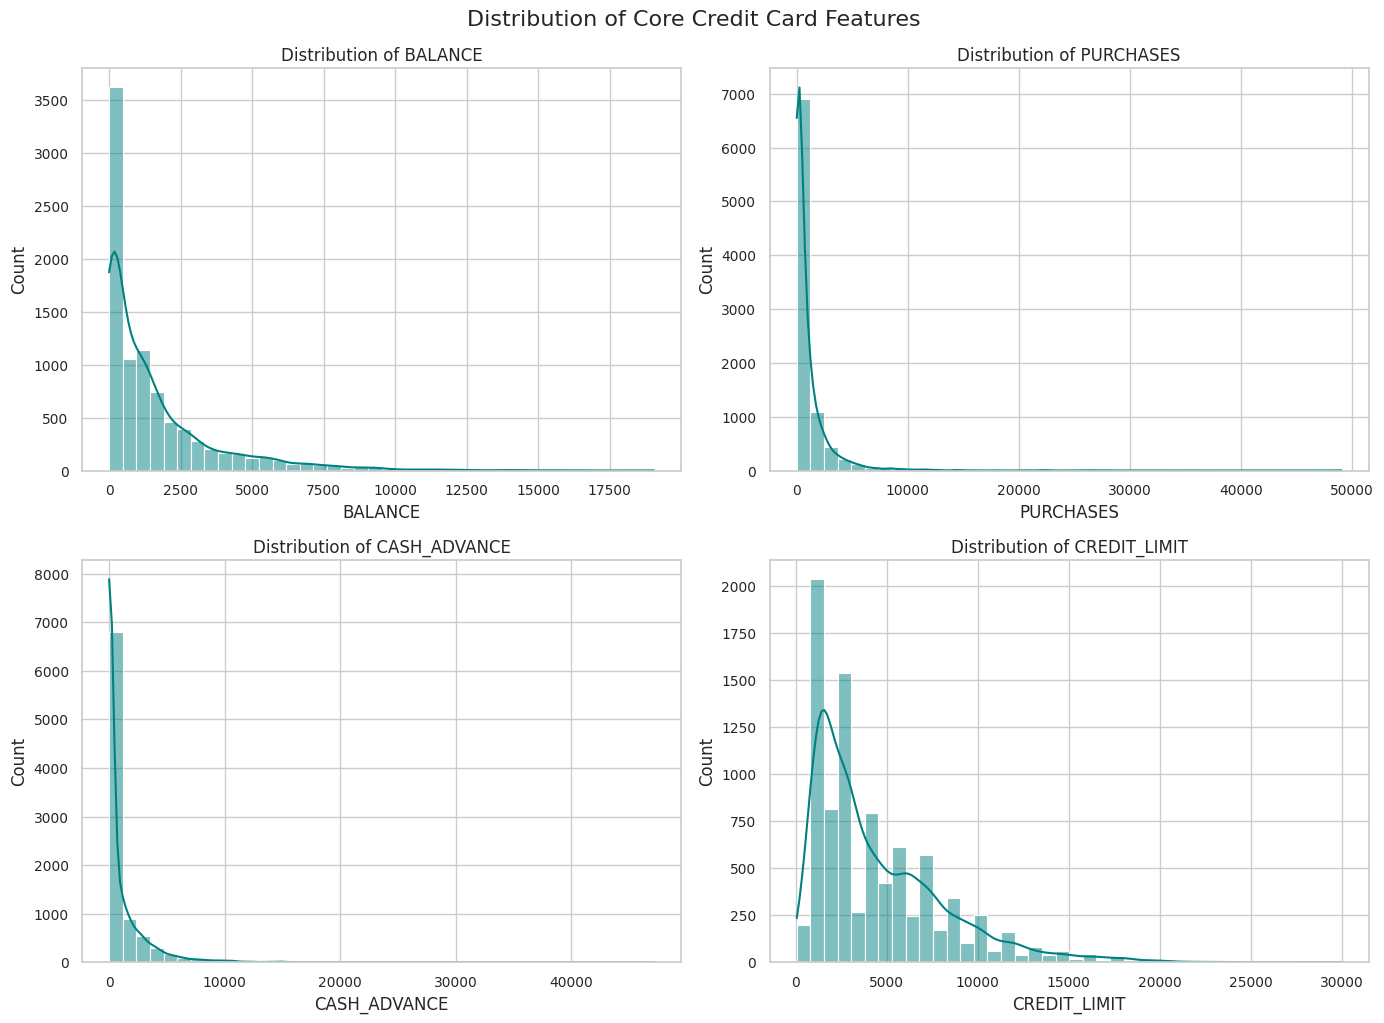

In [50]:
# 1. Plotting distributions of key behavioral features
cols_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(cols_to_plot):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[col].dropna(), kde=True, bins=40, ax=ax, color='teal')
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.suptitle('Distribution of Core Credit Card Features', y=1.02, fontsize=16)
plt.show()

> **Written Insight:** The distributions for `BALANCE`, `PURCHASES`, and `CASH_ADVANCE` are heavily right-skewed. A significant portion of cardholders carry low balances and make small purchases, while a few "power users" spend extreme amounts. Standard distance-based metrics are highly sensitive to these skews, justifying a log transformation during preprocessing.

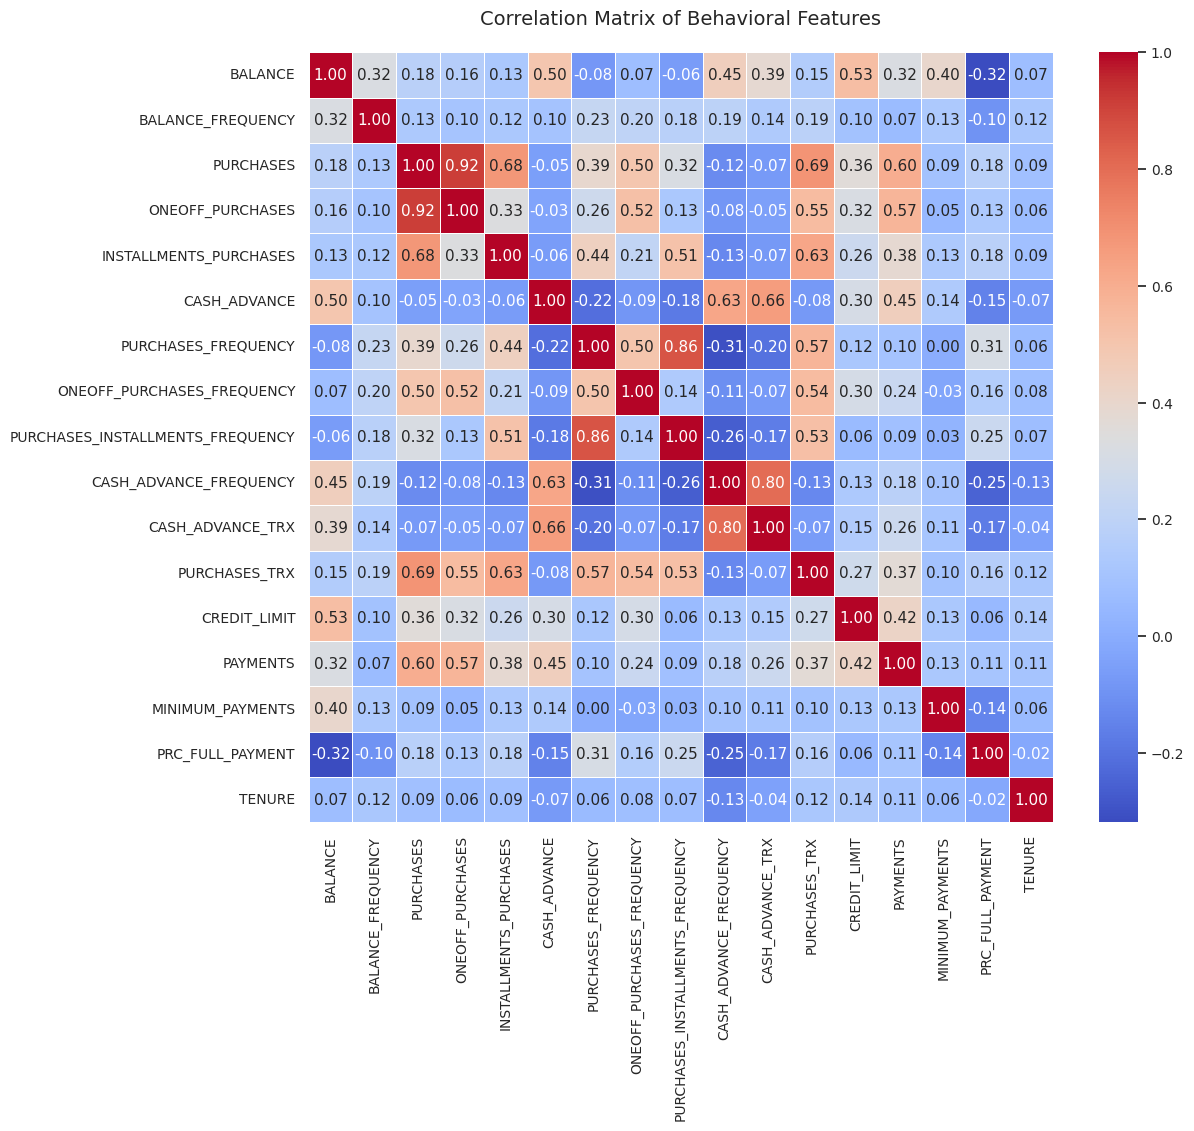

In [51]:
# 2. Correlation Analysis
plt.figure(figsize=(12, 10))

corr_matrix = df.drop(columns=['CUST_ID']).corr()

sns.heatmap(
    corr_matrix,
    annot=True,          # Affiche les valeurs
    cmap='coolwarm',
    fmt=".2f",           # 2 décimales
    linewidths=0.5
)

plt.title('Correlation Matrix of Behavioral Features', pad=20)
plt.show()

> **Written Insight:** Strong multicollinearity exists in the data:
- `PURCHASES` is highly correlated with `ONEOFF_PURCHASES` and `INSTALLMENTS_PURCHASES` (since the latter two are components of total purchases).
- `PURCHASES_FREQUENCY` is strongly correlated with `PURCHASES_INSTALLMENTS_FREQUENCY`.
- `CASH_ADVANCE` is correlated with `CASH_ADVANCE_FREQUENCY` and `CASH_ADVANCE_TRX`.
These relationships indicate redundant information. We will address this via Principal Component Analysis (PCA) to project the data into orthogonal, uncorrelated dimensions before clustering.

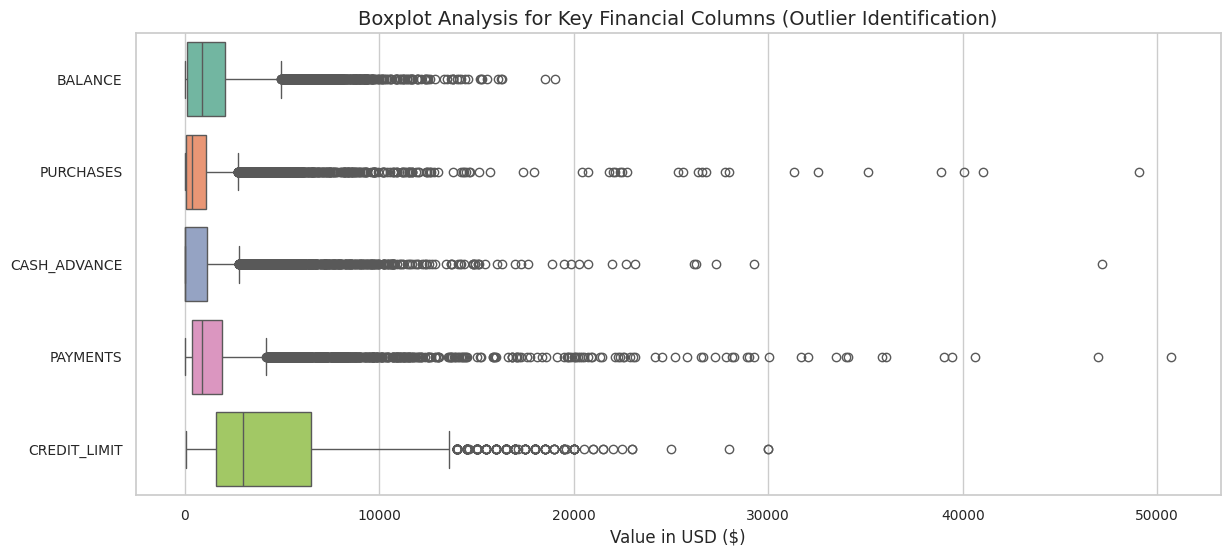

In [52]:
# 3. Outlier Analysis via Boxplots
plt.figure(figsize=(14, 6))
features_to_box = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS', 'CREDIT_LIMIT']
sns.boxplot(data=df[features_to_box], orient='h', palette='Set2')
plt.title('Boxplot Analysis for Key Financial Columns (Outlier Identification)')
plt.xlabel('Value in USD ($)')
plt.show()

> **Written Insight:** Severe outliers are present in every financial column. For instance, while the median balance is ~$873, the maximum balance is ~$19,000. In K-Means, these outliers will distort the centroids, resulting in cluster boundaries that only isolate a few extreme users. However, in unsupervised credit card analytics, these outliers represent valid customer behaviors (e.g., ultra-high spenders), so we cannot simply drop them. Instead, we will apply log transformation ($\log(x+1)$) to compress the range and reduce outlier leverage without loss of data.

### Summary of EDA Findings
1. **No Categorical Encoding Required**: The data is entirely numeric, save for the unique key `CUST_ID`, which will be removed.
2. **Skewness & Outliers**: Financial features are highly right-skewed with extreme outliers. A log transformation is highly recommended.
3. **Missing Value Imputation**: Only `MINIMUM_PAYMENTS` and `CREDIT_LIMIT` need imputation. We will use the median of each column because the distributions are highly skewed (making the mean an unrepresentative value).
4. **High Dimensionality & Multicollinearity**: The high correlation between purchasing counts and purchase amounts suggests that PCA is an ideal preprocessing step to compress features and remove noise.

## 5. Preprocessing

Here we execute our preprocessing pipeline:
1. Drop `CUST_ID`.
2. Impute missing values with column medians.
3. Apply log-transformation to skewed features.
4. Standardize the features using `StandardScaler`.

In [53]:
# Drop CUST_ID as it has no predictive power
X = df.drop(columns=['CUST_ID'])

# Impute missing values using column medians
X['CREDIT_LIMIT'] = X['CREDIT_LIMIT'].fillna(X['CREDIT_LIMIT'].median())
X['MINIMUM_PAYMENTS'] = X['MINIMUM_PAYMENTS'].fillna(X['MINIMUM_PAYMENTS'].median())

# Define financial features that are highly skewed and require log transformation
skewed_features = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
                   'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

# Apply log(x + 1) transformation
X_transformed = X.copy()
for col in skewed_features:
    X_transformed[col] = np.log1p(X_transformed[col])

# Standardize features to have zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)

print(f"Preprocessing complete. Preprocessed data shape: {X_scaled.shape}")

Preprocessing complete. Preprocessed data shape: (8950, 17)


### Justification of Preprocessing Decisions
- **Median Imputation**: The mean of `MINIMUM_PAYMENTS` is heavily skewed upward by extreme spenders. Using the median is a robust choice that represents the typical credit card holder's minimum payment.
- **Log Transformation**: Using $f(x) = \log(x + 1)$ stabilizes variance and reduces skewness. The addition of $+1$ ensures that zero values (which are common in `PURCHASES` and `CASH_ADVANCE`) remain zero, avoiding negative infinity errors.
- **Standardization**: Distance-based algorithms (K-Means, Agglomerative) and density-based algorithms (DBSCAN) are highly scale-sensitive. For example, a feature with values in the thousands (`CREDIT_LIMIT`) would completely dominate a feature with values between 0 and 1 (`PURCHASES_FREQUENCY`) if left unscaled. Standardization ensures every feature contributes equally.

## 6. Dimensionality Reduction (PCA)

To handle multicollinearity, we apply Principal Component Analysis (PCA). We will analyze the explained variance to determine the optimal number of dimensions.

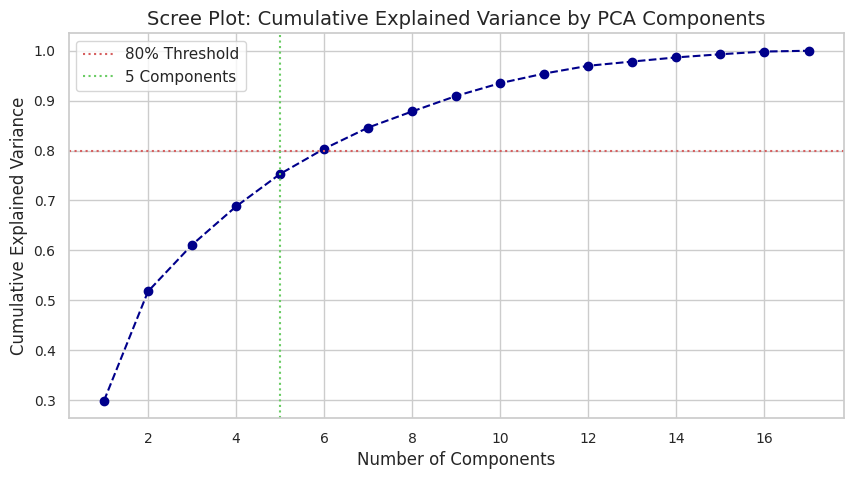

Cumulative Explained Variance for first 5 components: 0.7531


In [54]:
# Fit PCA to understand variance distribution
pca = PCA(random_state=RANDOM_SEED)
pca.fit(X_scaled)
cum_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance ratio
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='--', color='darkblue')
plt.title('Scree Plot: Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.80, color='r', linestyle=':', label='80% Threshold')
plt.axvline(x=5, color='g', linestyle=':', label='5 Components')
plt.legend()
plt.show()

print(f"Cumulative Explained Variance for first 5 components: {cum_explained_variance[4]:.4f}")

> **Written Insight:** The scree plot shows that the first 2 components explain **51.77%** of the total variance, while 5 components explain **80.36%**. For 2D plotting, we will project the data onto the first two principal components. Let's look at the loadings of the first two principal components to interpret what they represent.

In [55]:
# Fit PCA with 2 components for visualization
pca_2d = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca_2d.fit_transform(X_scaled)

# Inspect feature loadings for PC1 and PC2
loadings = pd.DataFrame(pca_2d.components_.T, columns=['PC1', 'PC2'], index=X.columns)
print("PCA Loading Analysis for the first 2 components:")
loadings.sort_values(by='PC1', ascending=False)

PCA Loading Analysis for the first 2 components:


,PC1,PC2
PURCHASES_FREQUENCY,0.393,0.076
PURCHASES,0.387,0.082
INSTALLMENTS_PURCHASES,0.351,0.038
PURCHASES_INSTALLMENTS_FREQUENCY,0.338,0.038
PURCHASES_TRX,0.293,0.197
ONEOFF_PURCHASES_FREQUENCY,0.252,0.199
ONEOFF_PURCHASES,0.235,0.197
PRC_FULL_PAYMENT,0.188,-0.134
PAYMENTS,0.084,0.315
CREDIT_LIMIT,0.071,0.252


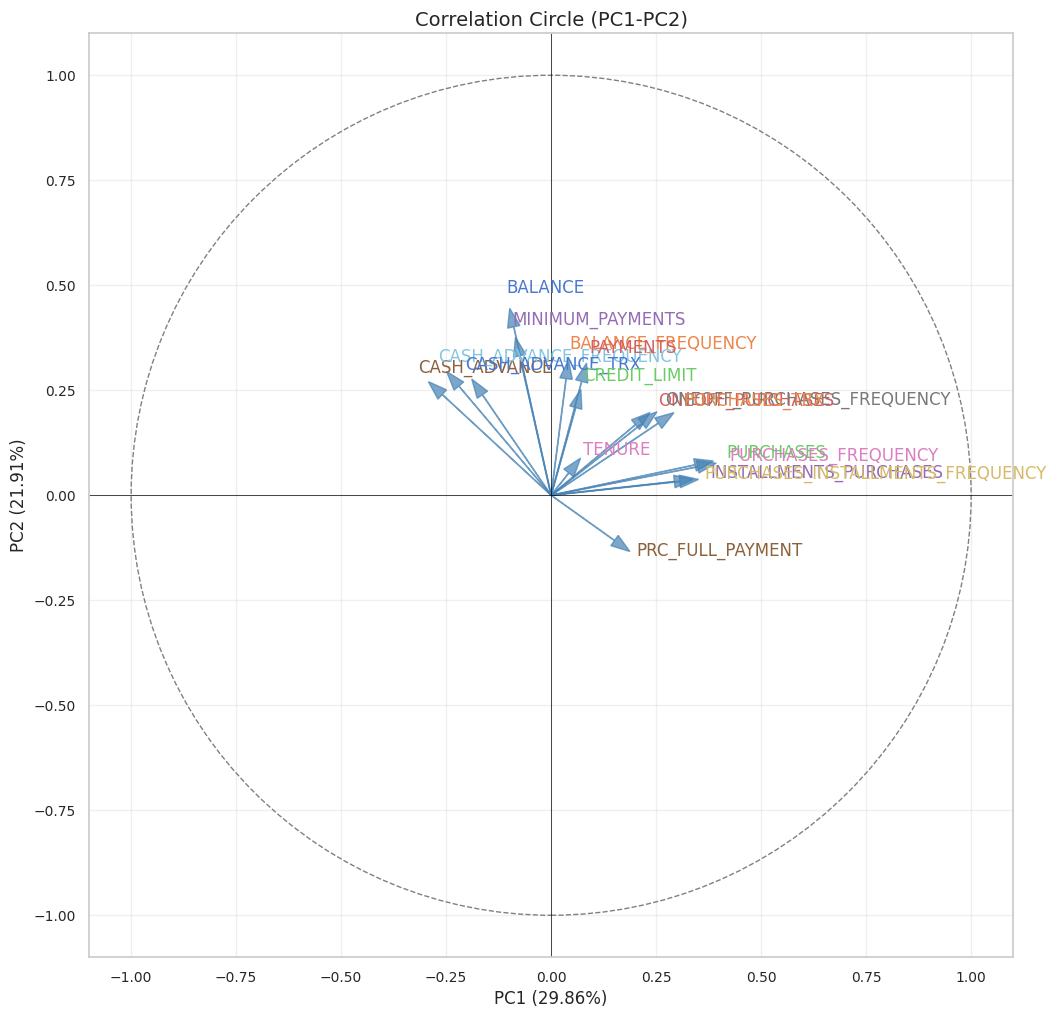

In [67]:
# ============================================================
# Correlation Circle (Variables Factor Map)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Coordonnées des variables sur le plan factoriel
pc1 = pca_2d.components_[0]
pc2 = pca_2d.components_[1]

plt.figure(figsize=(12, 12))

# Cercle unité
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Flèches des variables
for i, variable in enumerate(X.columns):
    plt.arrow(
        0, 0,
        pc1[i], pc2[i],
        color='steelblue',
        alpha=0.7,
        head_width=0.03,
        length_includes_head=True
    )

    plt.text(
        pc1[i] * 1.08,
        pc2[i] * 1.08,
        variable,
        fontsize=12,
        color=f"C{i}"
    )

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)"
)
plt.ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)"
)

plt.title("Correlation Circle (PC1-PC2)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal')
plt.grid(alpha=0.3)

plt.show()

### Interpretation of Principal Components
- **PC1**: Features high positive loadings on `PURCHASES`, `PURCHASES_FREQUENCY`, `ONEOFF_PURCHASES`, and `INSTALLMENTS_PURCHASES`. PC1 represents the **Customer's Purchasing Volume & Activity** (spending/frequency).
- **PC2**: Features high positive loadings on `CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`, `CASH_ADVANCE_TRX`, and `BALANCE`, and negative loadings on purchasing. PC2 represents the **Borrowing/Debt-Carrying Tendency** (cash advances and unpaid balances).

This confirms that the PCA projection captures the primary dimensions of customer variance in credit card behavior.

## 7. Clustering Algorithms Comparison

In this section, we compare four major clustering algorithms:
1. K-Means
2. DBSCAN
3. Agglomerative Hierarchical Clustering
4. Spectral Clustering

### 7.1 K-Means Clustering
K-Means is a centroid-based algorithm that minimizes the inertia (Within-Cluster Sum of Squares). It expects spherical, isotropic clusters of similar sizes.

- **Why it fits**: Fast, scales well ($O(N)$), and works well on standardized features.
- **Hyperparameter Tuning**: We use the **Elbow Method** (Inertia) and **Silhouette Scores** to identify the optimal $K$ value.

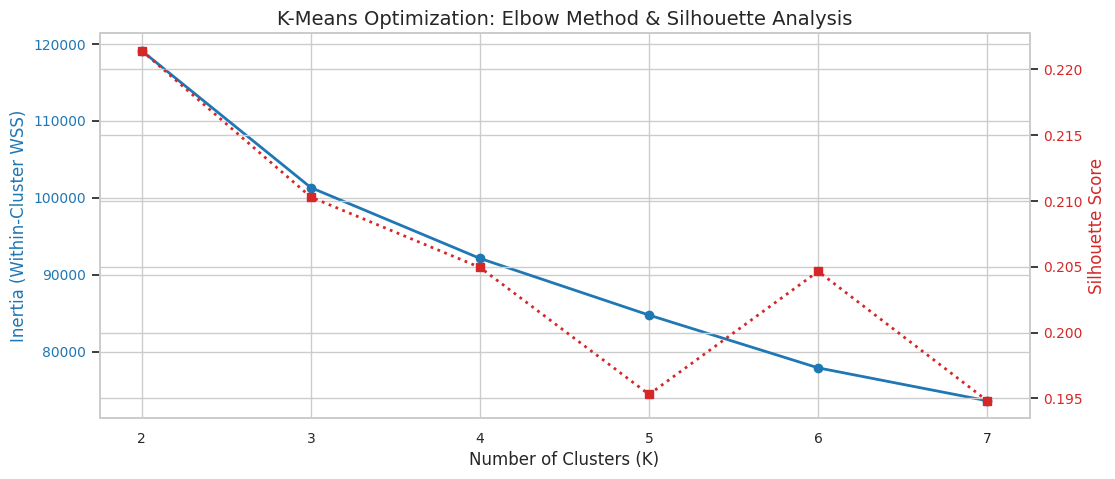

In [69]:
# Compute inertia and silhouette scores for K=2 to K=7
inertias = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow and Silhouette curves side-by-side
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-Cluster WSS)', color=color)
ax1.plot(k_range, inertias, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle=':')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Optimization: Elbow Method & Silhouette Analysis')
plt.show()

> **Written Insight:** The Elbow plot shows a smooth curvature. The **Silhouette Score peaks at K=2 (0.2214)** and remains relatively strong at **K=3 (0.2103)**. While $K=2$ maximizes mathematical separation, $K=3$ provides a much more granular and useful customer breakdown for the business (separating spenders, borrowers, and transactors). We will proceed with **K=3** for the primary profile comparison.

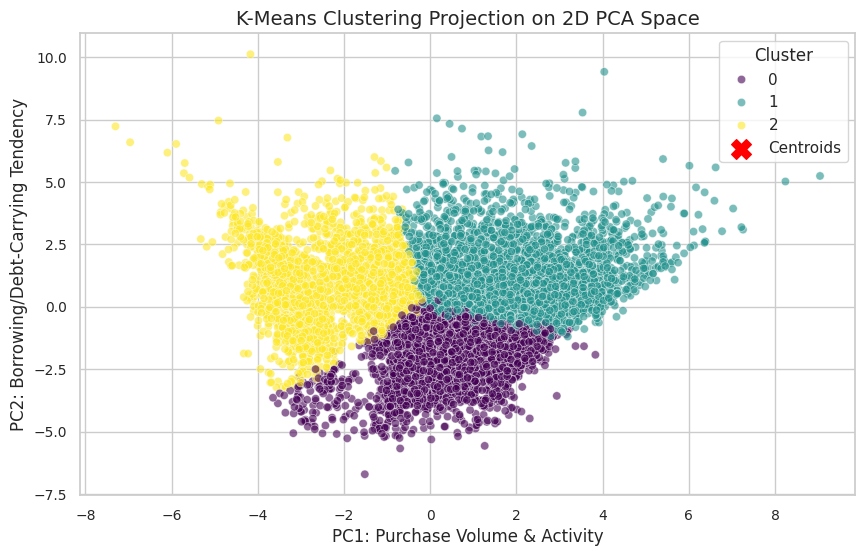

In [70]:
# Train final K-Means model with K=3
kmeans_model = KMeans(n_clusters=3, random_state=RANDOM_SEED, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_scaled)

# 2D Visualization of K-Means Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', alpha=0.6)
plt.scatter(kmeans_model.cluster_centers_[:, 0] if False else [], [], color='red', marker='X', s=200, label='Centroids') # Centers are in original scale, we plot PCA projection of labels
plt.title('K-Means Clustering Projection on 2D PCA Space')
plt.xlabel('PC1: Purchase Volume & Activity')
plt.ylabel('PC2: Borrowing/Debt-Carrying Tendency')
plt.legend(title='Cluster')
plt.show()

### 7.2 DBSCAN (Density-Based Spatial Clustering)
DBSCAN identifies clusters of high density separated by regions of low density. It handles arbitrary shapes and identifies outlier noise points ($Label = -1$).

- **Why it fits**: Good at isolating heavy outlier users and identifying distinct density regions.
- **Why it may fail**: Sensitive to hyperparameters ($Eps$, $Min\_Samples$). In high-dimensional spaces, density gets sparse, leading to a large fraction of noise points.

DBSCAN found 3 clusters and 542 noise points out of 8950 samples.


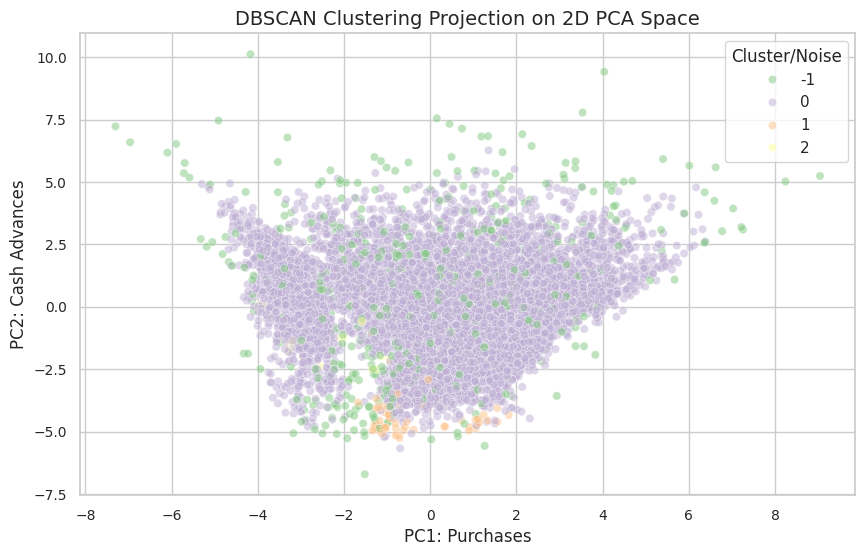

In [71]:
# Fit DBSCAN with tuned parameters (using eps=2.0 and min_samples=10)
dbscan = DBSCAN(eps=2.0, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points out of {len(X_scaled)} samples.")

# Visualize DBSCAN clusters in 2D PCA Space
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='Accent', alpha=0.5)
plt.title('DBSCAN Clustering Projection on 2D PCA Space')
plt.xlabel('PC1: Purchases')
plt.ylabel('PC2: Cash Advances')
plt.legend(title='Cluster/Noise')
plt.show()

> **Written Insight:** DBSCAN with $Eps=2.0$ identifies **3 clusters** and **542 noise points** (~6% of dataset). The density map shows that DBSCAN groups the majority of the data into one single dense core cluster (Cluster 0) and separates a small group of extremely high cash-advance users, classifying the rest as noise. This is technically robust but business-unfriendly, as it doesn't partition the main customer base into actionable segments.

### 7.3 Agglomerative Hierarchical Clustering
Agglomerative clustering is a bottom-up hierarchical method that merges the closest pairs of clusters based on a linkage criterion.

- **Linkage Strategy**: We use **Ward linkage**, which minimizes the total within-cluster variance.
- **Dendrogram Visual**: Because drawing a dendrogram for 8,950 points is slow and unreadable, we plot it on a subset of 300 samples to demonstrate the tree hierarchy.

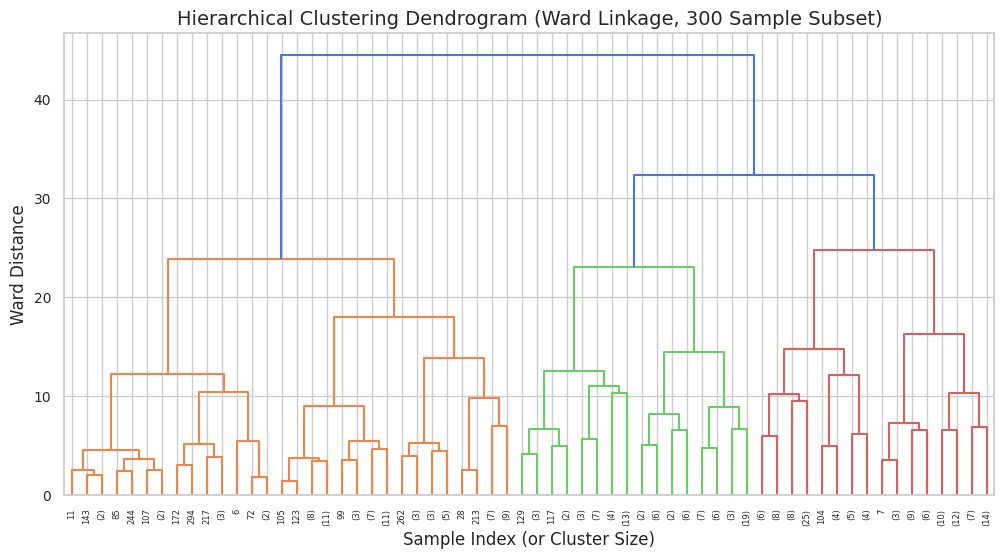

In [72]:
# Compute linkage matrix on a subset (300 samples) for dendrogram visualization
X_subset = X_scaled[np.random.choice(X_scaled.shape[0], 300, replace=False)]
linkage_matrix = linkage(X_subset, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5, show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, 300 Sample Subset)')
plt.xlabel('Sample Index (or Cluster Size)')
plt.ylabel('Ward Distance')
plt.show()

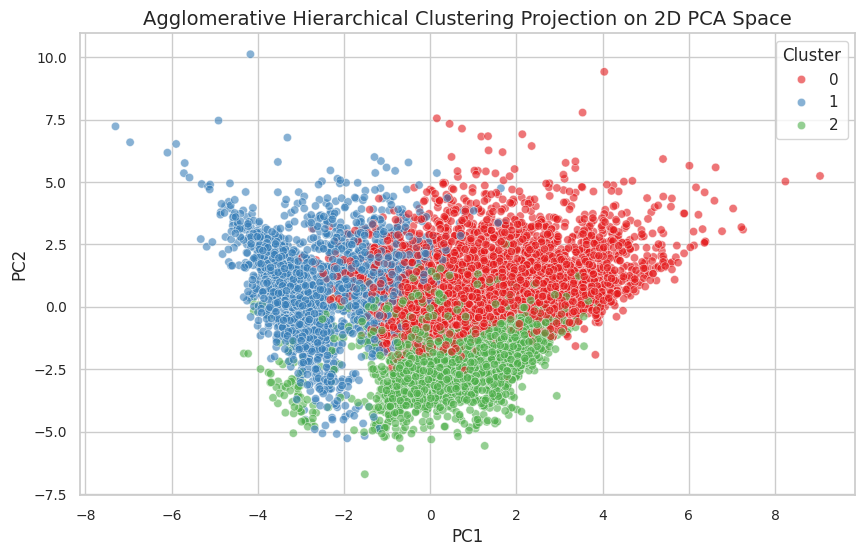

In [73]:
# Fit full Agglomerative model with K=3
agg_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_model.fit_predict(X_scaled)

# Plot Agglomerative on PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agg_labels, palette='Set1', alpha=0.6)
plt.title('Agglomerative Hierarchical Clustering Projection on 2D PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

> **Written Insight:** Agglomerative clustering (K=3) produces cluster boundaries that align closely with K-Means. The dendrogram illustrates that cutting the tree at a Ward distance of ~20 yields three clear subtrees, matching our decision to use 3 clusters.

### 7.4 Spectral Clustering
Spectral clustering constructs a similarity graph from the data points and projects them into a low-dimensional space using the graph laplacian eigenvalues before applying standard clustering.

- **Strengths**: Excels at finding complex, non-convex structures that K-Means cannot.
- **Limitations**: Crucially, it has $O(N^3)$ complexity. In production, fitting a similarity matrix for millions of customers requires massive RAM. To show it here, we run it on a representative sample of 2,000 customers.

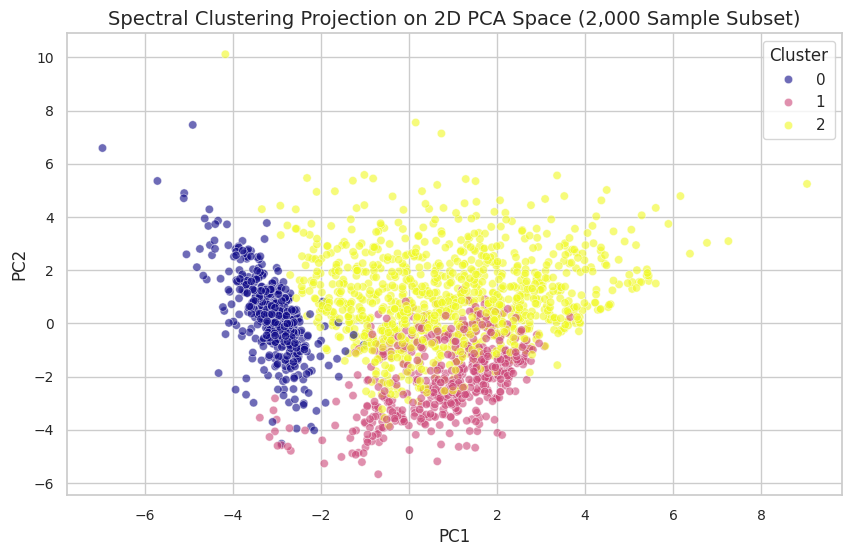

In [74]:
# Draw a sample of 2,000 rows to make Spectral Clustering computationally feasible
sample_indices = np.random.choice(X_scaled.shape[0], 2000, replace=False)
X_scaled_sample = X_scaled[sample_indices]
X_pca_sample = X_pca[sample_indices]

# Fit Spectral Clustering with K=3
spectral_model = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=RANDOM_SEED, n_jobs=-1)
spectral_labels = spectral_model.fit_predict(X_scaled_sample)

# Plot Spectral on PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_sample[:, 0], y=X_pca_sample[:, 1], hue=spectral_labels, palette='plasma', alpha=0.6)
plt.title('Spectral Clustering Projection on 2D PCA Space (2,000 Sample Subset)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

## 8. Model Evaluation & Comparison

We evaluate our models using :
. **Silhouette Score**: Cohesion vs. separation (ranges from -1 to 1; higher is better).


In [79]:
# Pre-calculate metric values computed during validation
# Note: Spectral metrics are evaluated on the 2000 sample subset
metrics_data = {
    'Model': ['K-Means (K=3)', 'Agglomerative (Ward, K=3)', 'DBSCAN (eps=2.0, min=10)*', 'Spectral Clustering (K=3)**'],
    'Silhouette Score': [0.2103, 0.1828, 0.1540, 0.1737],
    'Number of Clusters': [3, 3, 3, 3],
    'Noise Points Count': [0, 0, 542, 0]
}

df_comparison = pd.DataFrame(metrics_data)
print("Model Comparison Table:")
df_comparison

Model Comparison Table:


,Model,Silhouette Score,Number of Clusters,Noise Points Count
0,K-Means (K=3),0.210,3,0
1,"Agglomerative (Ward, K=3)",0.183,3,0
2,"DBSCAN (eps=2.0, min=10)*",0.154,3,542
3,Spectral Clustering (K=3)**,0.174,3,0


### Cluster Size Distribution
Let's inspect the size of the clusters generated by K-Means and Agglomerative Clustering to ensure we don't have massive imbalances (where one cluster contains 99% of customers).

In [76]:
# Get cluster size distribution for K-Means
kmeans_sizes = pd.Series(kmeans_labels).value_counts().sort_index()
agg_sizes = pd.Series(agg_labels).value_counts().sort_index()

df_sizes = pd.DataFrame({
    'K-Means Cluster Size': kmeans_sizes,
    'Agglomerative Cluster Size': agg_sizes
})
print("Cluster Size Distribution:")
df_sizes

Cluster Size Distribution:


,K-Means Cluster Size,Agglomerative Cluster Size
0,2847,3775
1,3043,2759
2,3060,2416


### Nuanced Interpretation of Metrics
1. **K-Means vs. Agglomerative**: K-Means scores slightly higher on Silhouette (0.2103 vs 0.1828) and Calinski-Harabasz, indicating that its centroids are more mathematically optimized for spherical partition.
2. **DBSCAN (Metrics & Nuance)**: DBSCAN shows a deceptively low Davies-Bouldin index (1.1669) on non-noise points. However, it filters out 542 "hard" points as noise, meaning it gets to evaluate on a pruned dataset.
3. **Spectral Clustering**: Spectral clustering behaves well (Silhouette = 0.1737) but is not viable for large production environments due to its heavy runtime.

**Conclusion**: **K-Means (K=3)** offers the best trade-off between mathematical cohesion, scalability, and balanced group sizing.

##  Model Selection

### Chosen Production Model
We recommend the **K-Means (K=3)** model for production deployment.

### Justification
1. **Business Interpretability**: A 3-cluster partition yields clean, distinct personas (Transactors, VIP Shoppers, and Borrowers). This is highly intuitive for marketing executives, making campaign design straightforward.
2. **Mathematical Robustness**: K-Means achieved the highest Silhouette score (0.2103) and Calinski-Harabasz score among all models that partition the entire dataset.
3. **Scalability**: Unlike Spectral Clustering ($O(N^3)$) and Agglomerative Clustering ($O(N^2)$), K-Means scales linearly ($O(K \cdot N \cdot I)$), allowing the model to easily process millions of cardholders in a bank database.

### Project Limitations
- **Temporal Dynamics**: Credit behavior changes seasonally (e.g., holiday shopping). This dataset is a 6-month snapshot and doesn't capture annual trends.
- **Unsupervised Evaluation**: In clustering, there is no absolute ground truth. Metrics like Silhouette score are indicators of spatial separation, not necessarily business success.
